Results:

1. ROI for Italy campaigns is: **-6.18%**
2. ROI for US DBM campaigns is: **-34.60%**


## Recommendations

It seems that despite high spending in the US, it is one of the most unprofitable markets, while Netherlands and Russia has better overall results.

We can see that DBMs do not drive that many conversions (the target might be inbound marketing via email or other), while search has overall best results.

Therefore, **strictly from conversion** POV, I would do the following:

1. Shift around 30% of the budget from RT to Search.
2. Suggest reducing DBM budget even further and even consider stopping it.
3. Move on to country targeting.

I would **prioritize** countries like this:

1. **Netherlands** - Best results so far, easy to localize content. **Focus on Search and RT ads**.
2. **Russia** - Second best results, hard to localize but worth the shot. **Focus on search ads**.

## Process overview:

1. Filtering out customers in the spreadsheet
2. Combining files based on the uid
3. Summarizing revenue & costs
4. Breaking down based on the campaign & country
5. Ordering based on revenue
6. Analyzing data and decision making

## Images
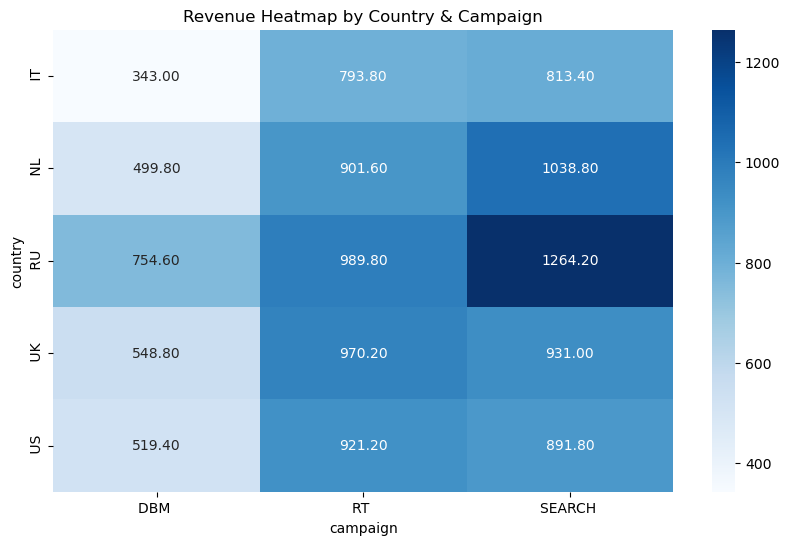

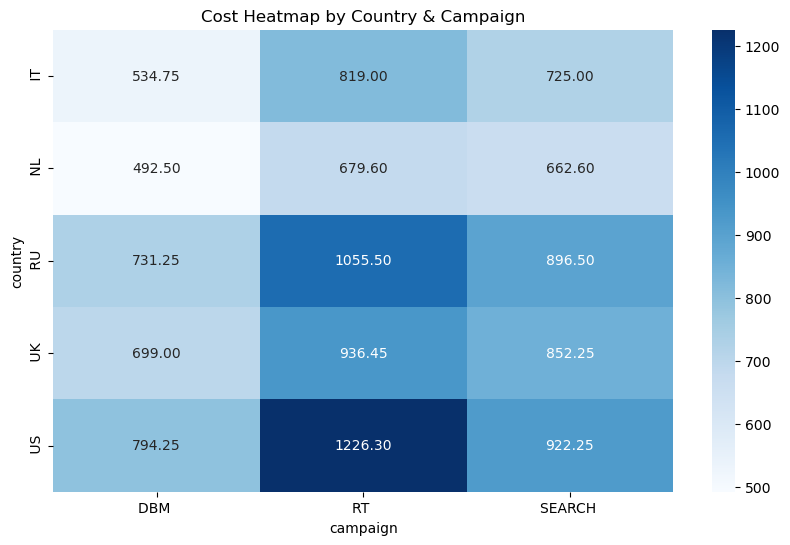

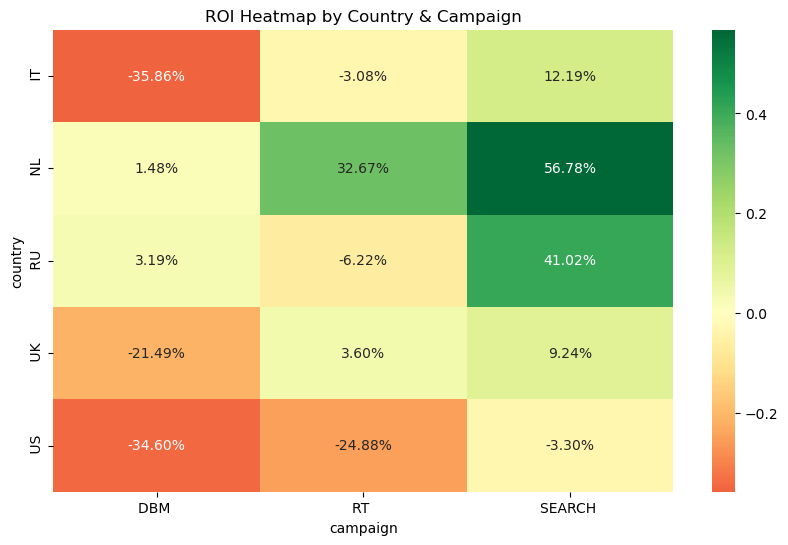

# Process - Code

## Step 1: Import files

In [1]:
import pandas as pd
path = r"C:\Users\ASUS\Documents\lead_gen_test_task__(2)_(2)_(1).xlsx"

df = pd.read_excel(path)
df2 = pd.read_excel(path, sheet_name='sheet2')


## Step 2: Separate visitors, leads and customers

In [2]:
df_minutes = df2[df2['lead_type'] == '3_minutes']
df_customer = df2[df2['lead_type'] == 'customer']
df_lead = df2[df2['lead_type'] == 'lead']


## Step 3: Merge customer data to the original spreadsheet

In [3]:
df_merged = pd.merge(df, df_customer[['uid', 'lead_type']], on='uid', how='left')

## Step 4: Add format data to include $ amounts (0 for non-customer, 9.8 for customer)

In [4]:
import numpy as np

df_merged['lead_type'] = np.where(
    df_merged['lead_type'] == 'customer',
    9.8,
    0
)

In [5]:
df_merged.rename(columns={'lead_type': 'revenue'}, inplace=True)

### Italy ROI

In [51]:
df_italy = df_merged[df_merged['country'] == ' IT']
italy_rev = df_italy['revenue'].sum()
italy_cost = df_italy['cost'].sum()
italy_roi = (italy_rev - italy_cost) / italy_cost
print(f"ROI for Italy campaigns is: {italy_roi:.2%}")

ROI for Italy campaigns is: -6.18%


### US DMB ROI

In [50]:
df_us_dbm = df_merged[(df_merged['country'] == ' US')]
df_us_dbm = df_us_dbm[df_us_dbm['campaign'] == 'DBM ']
us_dbm_rev = (df_us_dbm['revenue'].sum())
us_dbm_cost = (df_us_dbm['cost'].sum())
us_dbm_roi = (us_dbm_rev - us_dbm_cost) / us_dbm_cost
print(f"ROI for US DBM campaigns is: {us_dbm_roi:.2%}")

ROI for US DBM campaigns is: -34.60%


## Step 5: Create summary sheet

In [6]:
summary = (
    df_merged
    .groupby(['country', 'campaign'], as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        cost=('cost', 'sum'),
        roi=('revenue', lambda x: None),
        roas=('revenue', lambda x: None)
    )
)

summary['roi'] = (summary['revenue'] - summary['cost']) / summary['cost']
summary['roas'] = summary['revenue'] / summary['cost']

summary.sort_values(by='revenue', ascending=False)


,country,campaign,revenue,cost,roi,roas
8,RU,SEARCH,1264.2,896.50,0.410151,1.410151
5,NL,SEARCH,1038.8,662.60,0.567763,1.567763
7,RU,RT,989.8,1055.50,-0.062245,0.937755
10,UK,RT,970.2,936.45,0.036040,1.036040
11,UK,SEARCH,931.0,852.25,0.092402,1.092402
13,US,RT,921.2,1226.30,-0.248797,0.751203
4,NL,RT,901.6,679.60,0.326663,1.326663
14,US,SEARCH,891.8,922.25,-0.033017,0.966983
2,IT,SEARCH,813.4,725.00,0.121931,1.121931
1,IT,RT,793.8,819.00,-0.030769,0.969231


## Step 6: Create heatmaps of ROI, Revenue and Cost

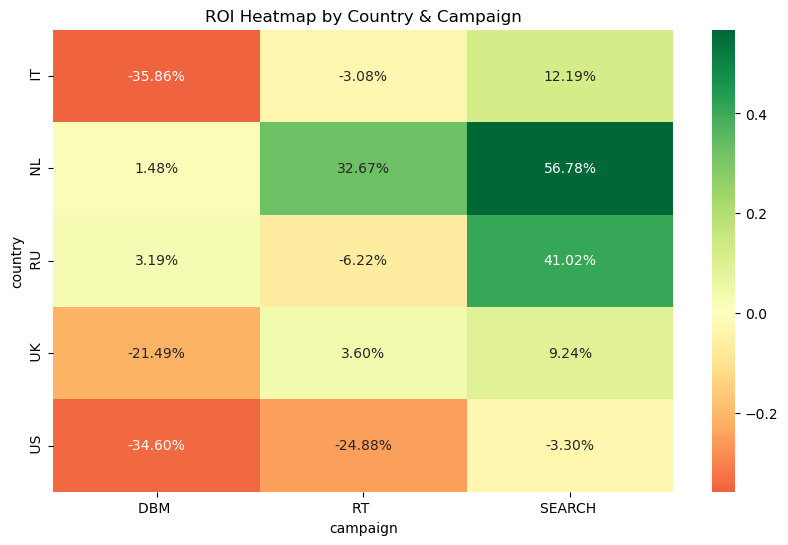

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = summary.pivot(index='country', columns='campaign', values='roi')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2%", cmap='RdYlGn', center=0)
plt.title("ROI Heatmap by Country & Campaign")
plt.show()


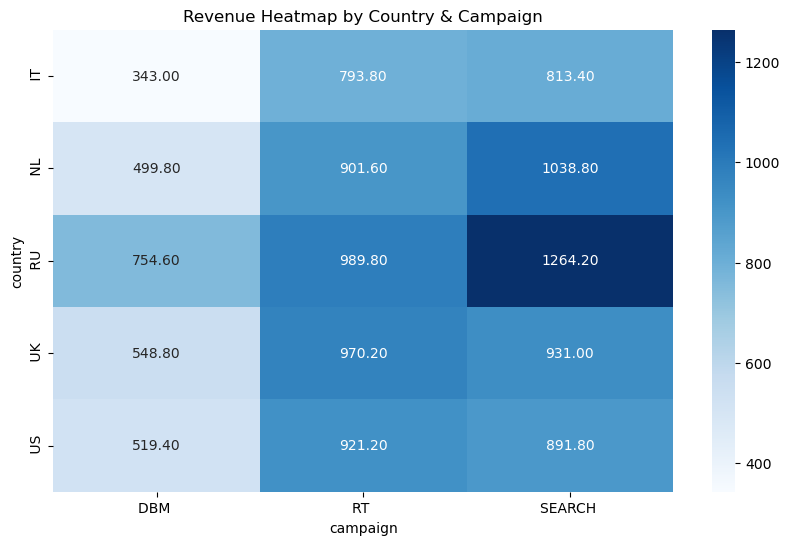

In [8]:
pivot = summary.pivot(index='country', columns='campaign', values='revenue')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Blues')
plt.title("Revenue Heatmap by Country & Campaign")
plt.show()


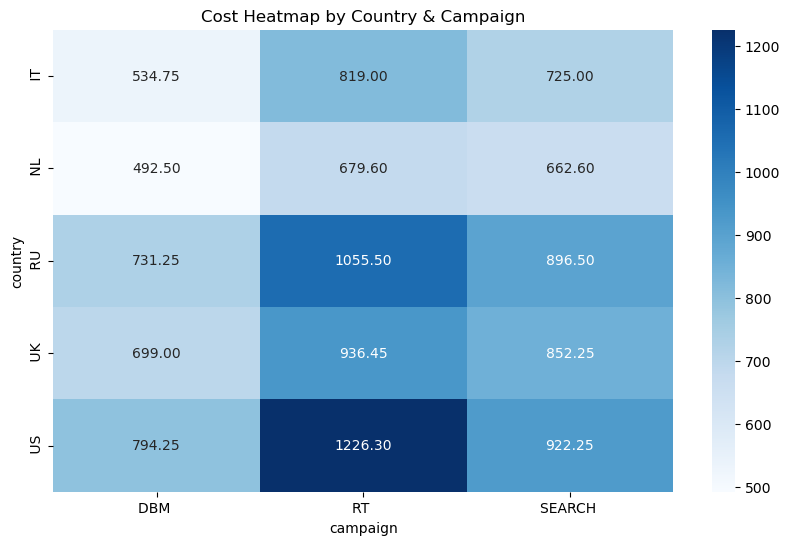

In [10]:
pivot = summary.pivot(index='country', columns='campaign', values='cost')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Blues')
plt.title("Cost Heatmap by Country & Campaign")
plt.show()
